Enter your heart rate (bpm):  120
Enter your Body Mass Index (BMI):  1324
Enter your blood pressure (mmHg):  546
Enter your age:  26



--- Health Health Analysis ---
Health Status: Risky Heart 
Advice: Consult a cardiologist for bradycardia or tachycardia.
Potential Risks: Tachycardia, Obesity-related cardiovascular risks, Hypertension
Recovery Tips: Practice mindfulness and stress reduction techniques.; Reduce sodium intake and avoid smoking.; Adopt a calorie-controlled diet and increase physical activity.


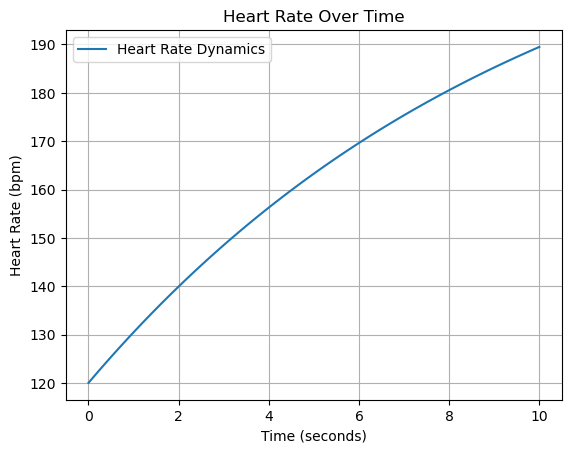

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import random

def heart_rate_model(t, y, heart_rate, bmi, blood_pressure, age):
    """
    ODE to model heart rate dynamics based on user inputs.
    """
    # Example coefficients based on research and general heart health dynamics
    stress_factor = 0.01 * (bmi - 22) + 0.02 * (blood_pressure - 120) + 0.03 * (heart_rate - 70)
    age_factor = 0.005 * (age - 35)
    
    # Heart rate changes dynamically with stress and age factors
    dydt = -0.1 * y + stress_factor + age_factor  # Simple linear model
    return dydt

def classify_health(heart_rate, bmi, blood_pressure, age):
    """
    Classify health based on input parameters.
    """
    if heart_rate < 50 or heart_rate > 100:
        return "Risky Heart ", "Consult a cardiologist for bradycardia or tachycardia."
    elif bmi > 30 or blood_pressure > 140:
        return "Good Heart ", "Focus on weight management and blood pressure control."
    else:
        return "Healthy Heart ", "Maintain a balanced diet and regular exercise."

def disease_prediction(heart_rate, bmi, blood_pressure):
    """
    Predict potential diseases based on input parameters.
    """
    risks = []
    if heart_rate < 60:
        risks.append("Bradycardia")
    if heart_rate > 100:
        risks.append("Tachycardia")
    if bmi > 30:
        risks.append("Obesity-related cardiovascular risks")
    if blood_pressure > 140:
        risks.append("Hypertension")
    return risks

def recovery_paths(risks):
    """
    Suggest recovery paths or tips based on predicted risks.
    """
    tips = []
    if "Bradycardia" in risks:
        tips.append("Perform regular aerobic exercises to improve heart rate.")
    if "Tachycardia" in risks:
        tips.append("Practice mindfulness and stress reduction techniques.")
    if "Hypertension" in risks:
        tips.append("Reduce sodium intake and avoid smoking.")
    if "Obesity-related cardiovascular risks" in risks:
        tips.append("Adopt a calorie-controlled diet and increase physical activity.")
    return tips

def main():
    # User inputs
    heart_rate = int(input("Enter your heart rate (bpm): "))
    bmi = float(input("Enter your Body Mass Index (BMI): "))
    blood_pressure = float(input("Enter your blood pressure (mmHg): "))
    age = int(input("Enter your age: "))
    
    # Solve the heart rate ODE
    t_span = (0, 10)  # Time interval (e.g., 10 seconds)
    y0 = heart_rate  # Initial heart rate
    sol = solve_ivp(heart_rate_model, t_span, [y0], args=(heart_rate, bmi, blood_pressure, age), t_eval=np.linspace(0, 10, 100))
    
    # Classify health
    health_status, advice = classify_health(heart_rate, bmi, blood_pressure, age)
    
    # Predict diseases
    risks = disease_prediction(heart_rate, bmi, blood_pressure)
    
    # Suggest recovery paths
    tips = recovery_paths(risks)
    
    # Output results
    print("\n--- Health Health Analysis ---")
    print(f"Health Status: {health_status}")
    print(f"Advice: {advice}")
    print(f"Potential Risks: {', '.join(risks) if risks else 'None'}")
    print(f"Recovery Tips: {'; '.join(tips) if tips else 'Keep maintaining a healthy lifestyle!'}")
    
    if health_status == "High Risk":
        print("Please consult the nearest cardiologist immediately.")
    elif health_status == "Moderate Risk":
        print("Consider visiting a doctor for a check-up.")

    # Plot the heart rate dynamics
    try:
        import matplotlib.pyplot as plt
        plt.plot(sol.t, sol.y[0], label="Heart Rate Dynamics")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Heart Rate (bpm)")
        plt.title("Heart Rate Over Time")
        plt.legend()
        plt.grid()
        plt.show()
    except ImportError:
        print("Matplotlib is not installed. Skipping the plot.")

if __name__ == "__main__":
    main()
